# Cluster-Level Feature Importance

This notebook selects **one final model per energy ticker** and then computes feature importance at the cluster/component level.

Selection rule:

1. Read the universal model comparison file: `results/model_comparison.csv`.
2. For each ticker, keep the **top 3 candidates by mean CPCV AUC**.
3. From those top 3, select the candidate with the **highest median CPCV path Sharpe**.
4. Refit only the selected final models on the pre-2022 training rows.
5. Report feature-level and cluster/component-level importance.

If Random Forest is still running, this notebook will select from whatever rows already exist in `results/model_comparison.csv`. Re-run it after RF finishes to select across both logistic and tree models.

In [7]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root from either the notebook folder or repo root."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "results").exists() and (candidate / "04_feature_importance").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root.")


PROJECT_ROOT = find_project_root()
FEATURE_IMPORTANCE_DIR = PROJECT_ROOT / "04_feature_importance"
RESULTS_DIR = PROJECT_ROOT / "results"

if str(FEATURE_IMPORTANCE_DIR) not in sys.path:
    sys.path.insert(0, str(FEATURE_IMPORTANCE_DIR))

from cluster_feature_importance import (  # noqa: E402
    ENERGY_TICKERS,
    fit_selected_model,
    read_model_comparison,
    select_top3_auc_then_sharpe,
)

COMPARISON_PATH = RESULTS_DIR / "model_comparison.csv"
TOP3_PATH = RESULTS_DIR / "feature_importance_top3_by_auc.csv"
SELECTED_PATH = RESULTS_DIR / "feature_importance_selected_models.csv"
FEATURE_IMPORTANCE_PATH = RESULTS_DIR / "feature_importance_feature_level.csv"
CLUSTER_IMPORTANCE_PATH = RESULTS_DIR / "feature_importance_cluster_level.csv"

print("Project root:", PROJECT_ROOT)
print("Comparison file:", COMPARISON_PATH)
print("Tickers:", ENERGY_TICKERS)

Project root: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw
Comparison file: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/model_comparison.csv
Tickers: ['cl1s', 'ho1s', 'rb1s', 'ng1s']


## 1. Load Model Comparison Results

The comparison CSV should contain one row per model candidate. The important fields for this notebook are:

- `ticker`
- `model_type`
- `tb_config_name`
- `model_name`
- `feature_method`
- `mean_auc`
- `median_path_trade_sharpe`
- `path_sharpe_iqr`

AUC decides the top 3. Sharpe only decides which of those top 3 becomes the final selected model for that ticker.

In [8]:
comparison_df = read_model_comparison(COMPARISON_PATH)

print(f"Loaded {len(comparison_df):,} model-comparison rows.")
print("Rows by model type and ticker:")
display(
    comparison_df
    .groupby(["model_type", "ticker"])
    .size()
    .unstack(fill_value=0)
)

preview_cols = [
    "model_type", "ticker", "tb_config_name", "feature_method", "model_name",
    "mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr", "num_days",
]
preview_cols = [col for col in preview_cols if col in comparison_df.columns]

print("Highest-AUC candidates currently available:")
display(
    comparison_df
    .sort_values(["mean_auc", "std_auc", "median_path_trade_sharpe"], ascending=[False, True, False])
    .loc[:, preview_cols]
    .head(12)
)

Loaded 40 model-comparison rows.
Rows by model type and ticker:


ticker,cl1s,ho1s,ng1s,rb1s
model_type,,,,
logistic_regression,5,5,5,5
random_forest,5,5,5,5


Highest-AUC candidates currently available:


,model_type,ticker,tb_config_name,feature_method,model_name,mean_auc,std_auc,median_path_trade_sharpe,path_sharpe_iqr,num_days
5,logistic_regression,ho1s,garman_klass_10d_tp2_sl2,pca,l2_C0.1,0.736165,0.159956,0.631422,0.169486,10
6,logistic_regression,ho1s,garman_klass_10d_tp2_sl2,corr_cluster,l2_C1,0.728295,0.162535,0.556040,0.112878,10
7,logistic_regression,ho1s,garman_klass_10d_tp2_sl2,corr_cluster,l2_C0.1,0.726719,0.154470,0.541245,0.118433,10
8,logistic_regression,ho1s,garman_klass_10d_tp2_sl2,pca,l2_C1,0.716311,0.164492,0.625645,0.182765,10
9,logistic_regression,ho1s,ewma_10d_tp1_5_sl1_5,pca,l2_C0.1,0.706984,0.151281,0.397454,0.145493,10
25,random_forest,ho1s,ewma_5d_tp2_sl2,pca,rf_medium_depth,0.659588,0.165142,0.396755,0.141361,5
26,random_forest,ho1s,ewma_5d_tp2_sl2,pca,rf_shallow,0.643674,0.171454,0.394057,0.135976,5
20,random_forest,cl1s,parkinson_10d_tp2_sl2,corr_cluster,rf_shallow,0.643080,0.192026,0.421916,0.015622,10
21,random_forest,cl1s,garman_klass_10d_tp2_sl2,corr_cluster,rf_shallow,0.643080,0.192026,0.420381,0.015978,10
22,random_forest,cl1s,parkinson_10d_tp2_sl2,corr_cluster,rf_medium_depth,0.635559,0.190991,0.422354,0.013313,10


## 2. Select One Final Model Per Ticker

The selection is deliberately a **two-step rule**.

Step 1: For each ticker, sort all candidate models by `mean_auc` descending and keep only the **top 3 AUC candidates**.

Step 2: Within those 3 candidates only, select the model with the highest `median_path_trade_sharpe`.

Tie-breakers:

1. If two candidates have the same median Sharpe, prefer the lower `path_sharpe_iqr`, meaning the tighter Sharpe distribution.
2. If still tied, prefer the higher `mean_auc`.
3. If still tied, prefer the lower `std_auc`.

So AUC controls which models are allowed into the final shortlist. Median path Sharpe chooses the final model from that shortlist.


In [9]:
top3_by_auc, selected_models = select_top3_auc_then_sharpe(comparison_df)

selection_cols = [
    "ticker", "auc_rank_within_ticker", "model_type", "tb_config_name", "feature_method", "model_name",
    "mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr", "n_cpcv_paths", "num_days",
    "penalty", "C", "l1_ratio", "n_estimators", "max_depth", "min_samples_leaf", "max_features", "class_weight",
]
selection_cols = [col for col in selection_cols if col in top3_by_auc.columns]

selected_key_cols = ["ticker", "model_type", "tb_config_name", "feature_method", "model_name"]
selected_keys = selected_models[selected_key_cols].drop_duplicates().assign(selected_from_top3=True)

top3_display = top3_by_auc.merge(selected_keys, on=selected_key_cols, how="left")
top3_display["selected_from_top3"] = top3_display["selected_from_top3"].fillna(False)

top3_display["candidate_label"] = (
    top3_display["model_type"].astype(str)
    + " | " + top3_display["model_name"].astype(str)
    + " | " + top3_display["feature_method"].astype(str)
)

print("Step 1: top 3 by AUC for each ticker. The selected row is chosen in Step 2.")
display_cols = selection_cols + ["selected_from_top3"]
display_cols = [col for col in display_cols if col in top3_display.columns]
display(top3_display.loc[:, display_cols].sort_values(["ticker", "auc_rank_within_ticker"]))

selected_cols = [col for col in selection_cols if col != "auc_rank_within_ticker"] + ["selection_rule"]
selected_cols = [col for col in selected_models.columns if col in selected_cols]

print("Step 2: final selected model from each ticker's AUC top 3, ranked by highest median path Sharpe.")
display(selected_models.loc[:, selected_cols].sort_values("ticker"))


Step 1: top 3 by AUC for each ticker. The selected row is chosen in Step 2.


,ticker,auc_rank_within_ticker,model_type,tb_config_name,feature_method,model_name,mean_auc,std_auc,median_path_trade_sharpe,path_sharpe_iqr,n_cpcv_paths,num_days,penalty,C,l1_ratio,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,selected_from_top3
0,cl1s,1,random_forest,parkinson_10d_tp2_sl2,corr_cluster,rf_shallow,0.643080,0.192026,0.421916,0.015622,7,10,NaN,NaN,NaN,300.0,4.0,10.0,sqrt,balanced,False
1,cl1s,2,random_forest,garman_klass_10d_tp2_sl2,corr_cluster,rf_shallow,0.643080,0.192026,0.420381,0.015978,7,10,NaN,NaN,NaN,300.0,4.0,10.0,sqrt,balanced,False
2,cl1s,3,random_forest,parkinson_10d_tp2_sl2,corr_cluster,rf_medium_depth,0.635559,0.190991,0.422354,0.013313,7,10,NaN,NaN,NaN,500.0,8.0,8.0,sqrt,balanced,True
3,ho1s,1,logistic_regression,garman_klass_10d_tp2_sl2,pca,l2_C0.1,0.736165,0.159956,0.631422,0.169486,7,10,l2,0.1,NaN,NaN,NaN,NaN,NaN,balanced,True
4,ho1s,2,logistic_regression,garman_klass_10d_tp2_sl2,corr_cluster,l2_C1,0.728295,0.162535,0.556040,0.112878,7,10,l2,1.0,NaN,NaN,NaN,NaN,NaN,balanced,False
5,ho1s,3,logistic_regression,garman_klass_10d_tp2_sl2,corr_cluster,l2_C0.1,0.726719,0.154470,0.541245,0.118433,7,10,l2,0.1,NaN,NaN,NaN,NaN,NaN,balanced,False
6,ng1s,1,logistic_regression,garman_klass_10d_tp2_sl2,corr_cluster,l1_C1,0.619671,0.199402,0.328293,0.098420,7,10,l1,1.0,NaN,NaN,NaN,NaN,NaN,balanced,True
7,ng1s,2,logistic_regression,parkinson_10d_tp2_sl2,corr_cluster,l1_C1,0.619671,0.199402,0.328038,0.092174,7,10,l1,1.0,NaN,NaN,NaN,NaN,NaN,balanced,False
8,ng1s,3,logistic_regression,garman_klass_10d_tp2_sl2,pca,l2_C1,0.604495,0.180180,0.319655,0.405498,7,10,l2,1.0,NaN,NaN,NaN,NaN,NaN,balanced,False
9,rb1s,1,logistic_regression,garman_klass_10d_tp2_sl2,pca,l2_C0.1,0.551840,0.086230,0.050307,0.038364,7,10,l2,0.1,NaN,NaN,NaN,NaN,NaN,balanced,True


Step 2: final selected model from each ticker's AUC top 3, ranked by highest median path Sharpe.


,model_type,ticker,tb_config_name,feature_method,mean_auc,std_auc,n_cpcv_paths,median_path_trade_sharpe,path_sharpe_iqr,num_days,model_name,penalty,C,l1_ratio,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,selection_rule
0,random_forest,cl1s,parkinson_10d_tp2_sl2,corr_cluster,0.635559,0.190991,7,0.422354,0.013313,10,rf_medium_depth,NaN,NaN,NaN,500.0,8.0,8.0,sqrt,balanced,top3_mean_auc_then_highest_median_path_trade_s...
1,logistic_regression,ho1s,garman_klass_10d_tp2_sl2,pca,0.736165,0.159956,7,0.631422,0.169486,10,l2_C0.1,l2,0.1,NaN,NaN,NaN,NaN,NaN,balanced,top3_mean_auc_then_highest_median_path_trade_s...
2,logistic_regression,ng1s,garman_klass_10d_tp2_sl2,corr_cluster,0.619671,0.199402,7,0.328293,0.098420,10,l1_C1,l1,1.0,NaN,NaN,NaN,NaN,NaN,balanced,top3_mean_auc_then_highest_median_path_trade_s...
3,logistic_regression,rb1s,garman_klass_10d_tp2_sl2,pca,0.551840,0.086230,7,0.050307,0.038364,10,l2_C0.1,l2,0.1,NaN,NaN,NaN,NaN,NaN,balanced,top3_mean_auc_then_highest_median_path_trade_s...


## 3. Plot The Selection Rule

Each panel shows the three AUC-shortlisted candidates for one ticker.

- The bar height is `median_path_trade_sharpe`.
- The x-axis label includes the AUC rank from Step 1.
- The highlighted bar is the final selected model.

This makes the rule visible: **top 3 by AUC first, then highest median Sharpe inside those top 3**.


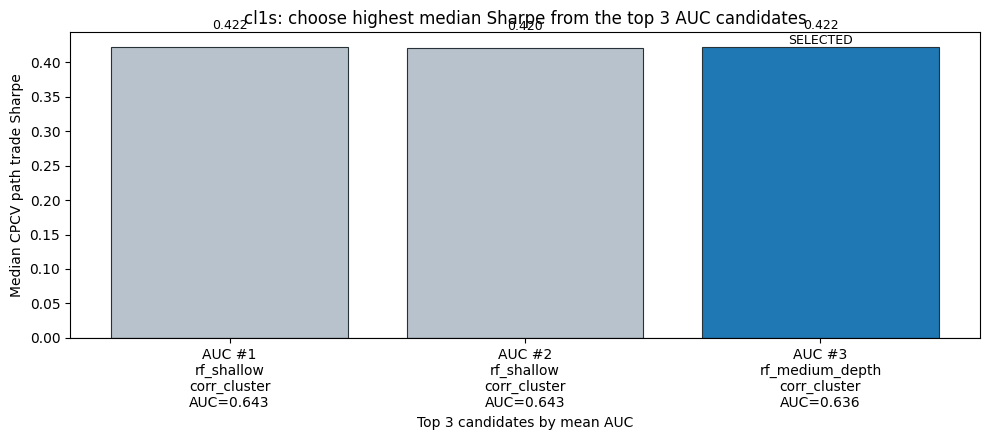

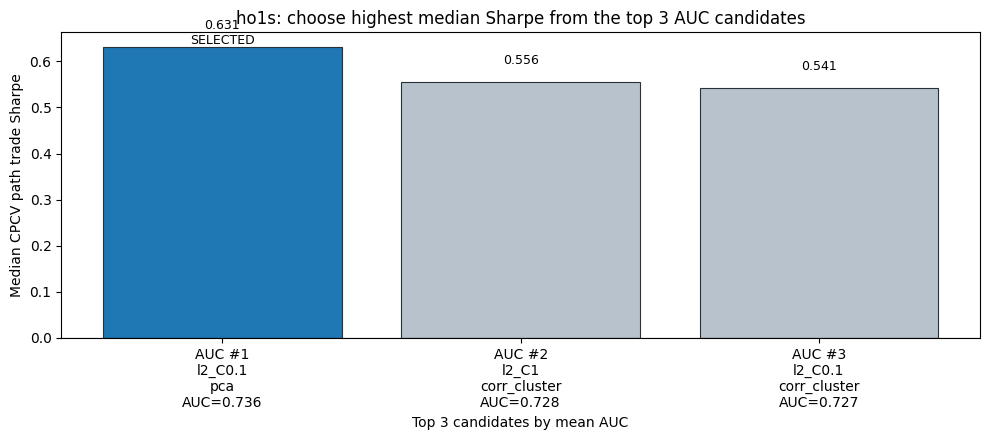

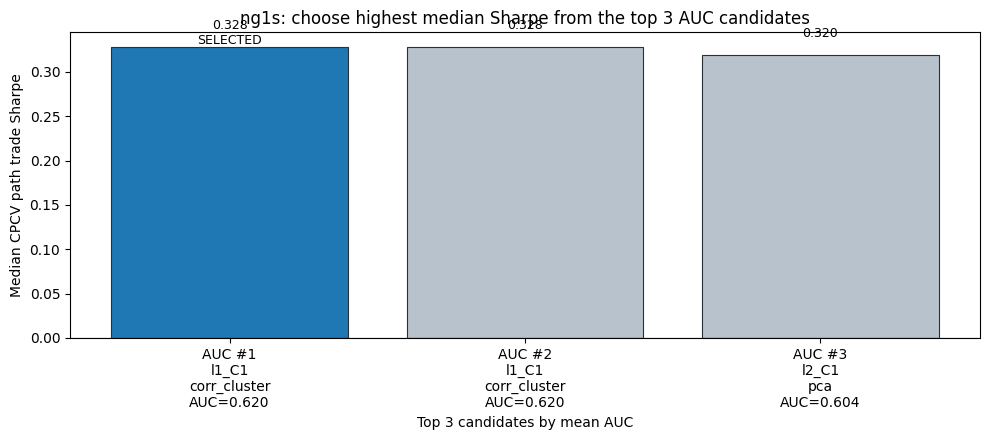

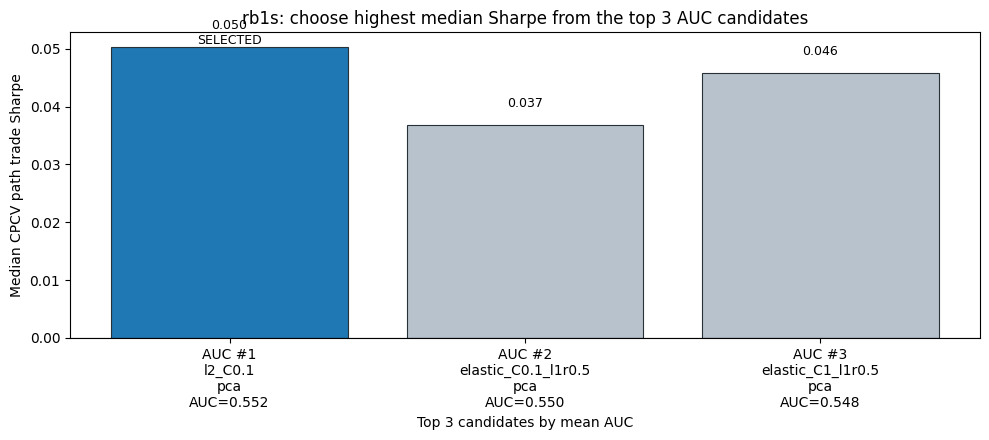

In [10]:
import matplotlib.pyplot as plt
from IPython.display import display

for ticker, ticker_top3 in top3_display.sort_values("auc_rank_within_ticker").groupby("ticker", sort=True):
    ticker_top3 = ticker_top3.sort_values("auc_rank_within_ticker").copy()
    labels = [
        f"AUC #{int(row.auc_rank_within_ticker)}\n{row.model_name}\n{row.feature_method}\nAUC={row.mean_auc:.3f}"
        for row in ticker_top3.itertuples(index=False)
    ]
    colors = ["#1f77b4" if selected else "#b8c2cc" for selected in ticker_top3["selected_from_top3"]]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(labels, ticker_top3["median_path_trade_sharpe"], color=colors, edgecolor="#263238", linewidth=0.8)
    ax.set_title(f"{ticker}: choose highest median Sharpe from the top 3 AUC candidates")
    ax.set_ylabel("Median CPCV path trade Sharpe")
    ax.set_xlabel("Top 3 candidates by mean AUC")
    ax.axhline(0, color="#263238", linewidth=0.8)

    for bar, row in zip(bars, ticker_top3.itertuples(index=False)):
        label = "SELECTED" if row.selected_from_top3 else ""
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row.median_path_trade_sharpe:.3f}\n{label}",
            ha="center",
            va="bottom" if bar.get_height() >= 0 else "top",
            fontsize=9,
        )

    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## 4. Refit Selected Models and Compute Importance

The notebook now refits only the selected model for each ticker on pre-2022 training rows.

Importance definition:

- Logistic regression: absolute standardized coefficient magnitude.
- Random Forest: sklearn mean-decrease-in-impurity feature importance.
- Correlation-cluster models: the representative feature's importance is treated as the importance of the whole correlation cluster.
- PCA models: each principal component is reported as a component-level group.

In [11]:
feature_tables = []
cluster_tables = []
fit_rows = []

for _, selected_row in selected_models.sort_values("ticker").iterrows():
    label = (
        f"{selected_row['ticker']} | {selected_row['model_type']} | "
        f"{selected_row['tb_config_name']} | {selected_row['model_name']} | "
        f"{selected_row['feature_method']}"
    )
    print("Fitting:", label)

    feature_df, cluster_df, metadata = fit_selected_model(selected_row)
    feature_tables.append(feature_df)
    cluster_tables.append(cluster_df)
    fit_rows.append(
        {
            "ticker": selected_row["ticker"],
            "model_type": selected_row["model_type"],
            "tb_config_name": selected_row["tb_config_name"],
            "model_name": selected_row["model_name"],
            "feature_method": selected_row["feature_method"],
            "train_rows": metadata["train_rows"],
            "original_feature_count": metadata["original_feature_count"],
            "processed_feature_count": metadata["processed_feature_count"],
        }
    )

feature_importance_df = pd.concat(feature_tables, ignore_index=True)
cluster_importance_df = pd.concat(cluster_tables, ignore_index=True)
fit_summary_df = pd.DataFrame(fit_rows)

selected_models_with_fit = selected_models.merge(
    fit_summary_df,
    on=["ticker", "model_type", "tb_config_name", "model_name", "feature_method"],
    how="left",
)

print("Selected models with refit details:")
fit_display_cols = [
    "ticker", "model_type", "tb_config_name", "feature_method", "model_name",
    "mean_auc", "median_path_trade_sharpe", "train_rows", "original_feature_count", "processed_feature_count",
]
fit_display_cols = [col for col in fit_display_cols if col in selected_models_with_fit.columns]
display(selected_models_with_fit.loc[:, fit_display_cols].sort_values("ticker"))

Fitting: cl1s | random_forest | parkinson_10d_tp2_sl2 | rf_medium_depth | corr_cluster
Fitting: ho1s | logistic_regression | garman_klass_10d_tp2_sl2 | l2_C0.1 | pca
Fitting: ng1s | logistic_regression | garman_klass_10d_tp2_sl2 | l1_C1 | corr_cluster
Fitting: rb1s | logistic_regression | garman_klass_10d_tp2_sl2 | l2_C0.1 | pca
Selected models with refit details:


,ticker,model_type,tb_config_name,feature_method,model_name,mean_auc,median_path_trade_sharpe,train_rows,original_feature_count,processed_feature_count
0,cl1s,random_forest,parkinson_10d_tp2_sl2,corr_cluster,rf_medium_depth,0.635559,0.422354,333,145,70
1,ho1s,logistic_regression,garman_klass_10d_tp2_sl2,pca,l2_C0.1,0.736165,0.631422,61,145,17
2,ng1s,logistic_regression,garman_klass_10d_tp2_sl2,corr_cluster,l1_C1,0.619671,0.328293,68,145,68
3,rb1s,logistic_regression,garman_klass_10d_tp2_sl2,pca,l2_C0.1,0.551840,0.050307,504,145,26


## 5. Cluster-Level Importance

This table is the main output. It shows the most important feature groups for each selected ticker model.

For normal features, the group is just the feature itself. For correlation-clustered models, the group represents the selected cluster representative and the features it stands in for. For PCA models, the group is a PCA component.

In [12]:
TOP_N_CLUSTERS_PER_TICKER = 12

cluster_display_cols = [
    "ticker", "model_type", "tb_config_name", "model_name", "feature_method",
    "importance_group", "cluster_importance", "group_type", "cluster_n_features",
    "representative_model_features", "cluster_features", "dropped_cluster_features", "importance_type",
]
cluster_display_cols = [col for col in cluster_display_cols if col in cluster_importance_df.columns]

top_clusters = (
    cluster_importance_df
    .sort_values(["ticker", "cluster_importance"], ascending=[True, False])
    .groupby("ticker", group_keys=False)
    .head(TOP_N_CLUSTERS_PER_TICKER)
)

display(top_clusters.loc[:, cluster_display_cols])

,ticker,model_type,tb_config_name,model_name,feature_method,importance_group,cluster_importance,group_type,cluster_n_features,representative_model_features,cluster_features,dropped_cluster_features,importance_type
0,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,vol_ratio_63_126d,0.144375,single_feature,1,[vol_ratio_63_126d],[vol_ratio_63_126d],[],random_forest_mdi
1,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,"cluster_008: vol_63d (rep, n=4)",0.099200,correlation_cluster,4,[vol_63d],"[vol_63d, ewma_vol_63d, park_vol_63d, gk_vol_63d]","[ewma_vol_63d, park_vol_63d, gk_vol_63d]",random_forest_mdi
2,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,sma50_vs_sma100,0.070007,single_feature,1,[sma50_vs_sma100],[sma50_vs_sma100],[],random_forest_mdi
3,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,bb_lower_dist,0.031466,single_feature,1,[bb_lower_dist],[bb_lower_dist],[],random_forest_mdi
4,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,"cluster_007: atr_20d_pct (rep, n=18)",0.030825,correlation_cluster,18,[atr_20d_pct],"[vol_5d, vol_10d, vol_20d, ewma_vol_5d, ewma_v...","[vol_5d, vol_10d, vol_20d, ewma_vol_5d, ewma_v...",random_forest_mdi
5,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,bb_width,0.030081,single_feature,1,[bb_width],[bb_width],[],random_forest_mdi
6,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,"cluster_010: atr_20d (rep, n=4)",0.027256,correlation_cluster,4,[atr_20d],"[atr_5d, atr_10d, atr_14d, atr_20d]","[atr_5d, atr_10d, atr_14d]",random_forest_mdi
7,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,ret_126d,0.026363,single_feature,1,[ret_126d],[ret_126d],[],random_forest_mdi
8,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,sma100_slope,0.026306,single_feature,1,[sma100_slope],[sma100_slope],[],random_forest_mdi
9,cl1s,random_forest,parkinson_10d_tp2_sl2,rf_medium_depth,corr_cluster,ret_spread_20_63,0.026069,single_feature,1,[ret_spread_20_63],[ret_spread_20_63],[],random_forest_mdi


## 6. Visual Check

These bar charts show the top cluster/component groups per selected ticker model. They are only a visual summary; the CSV output below is the source of truth.

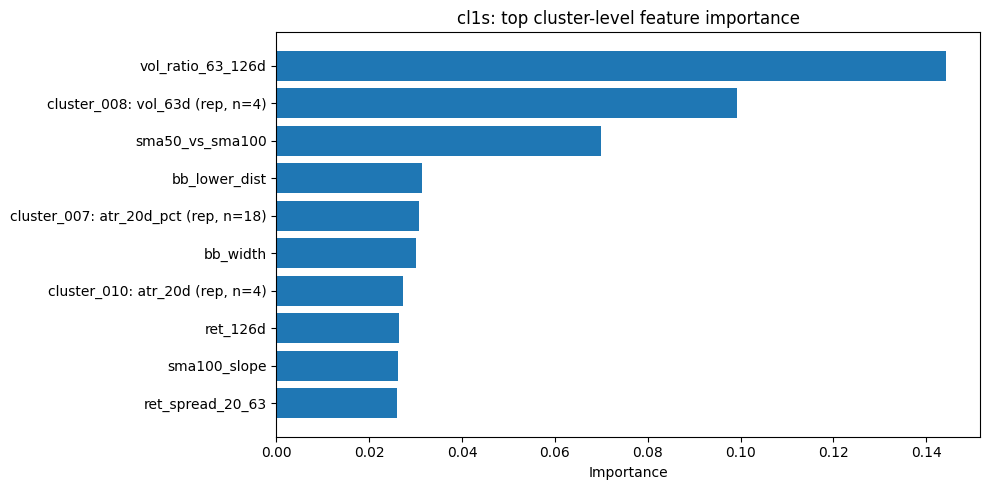

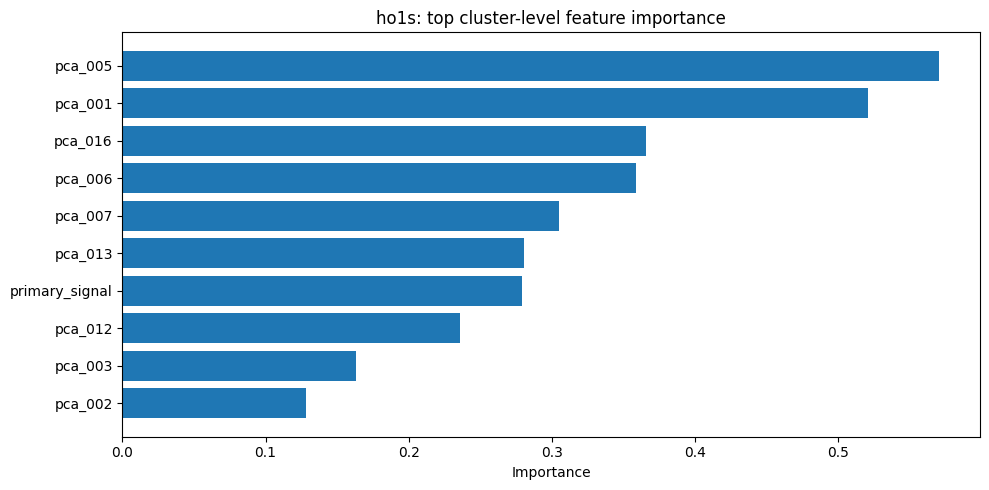

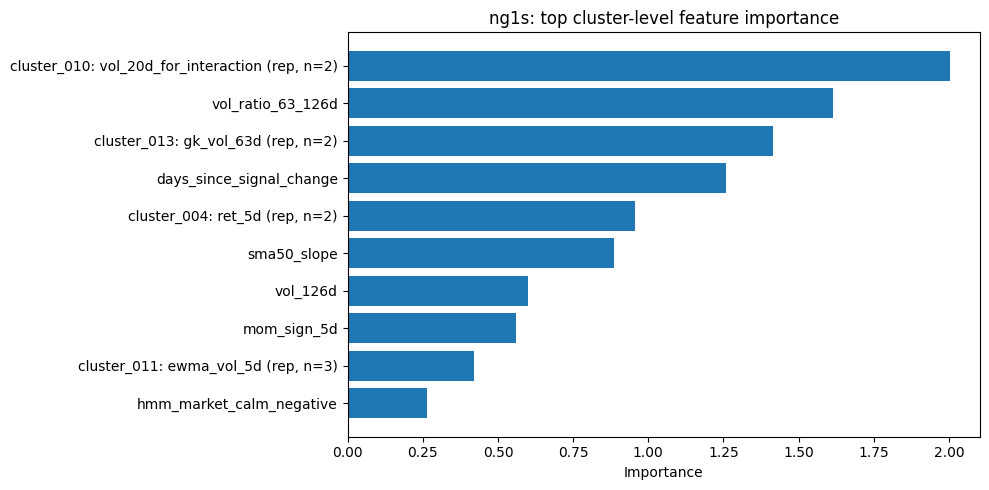

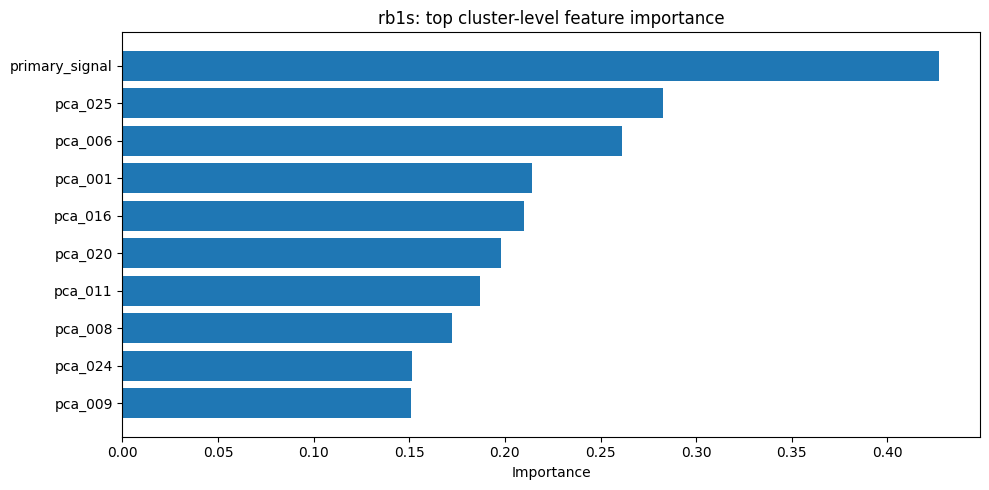

In [13]:
import matplotlib.pyplot as plt

for ticker, group in top_clusters.groupby("ticker", sort=True):
    plot_df = group.sort_values("cluster_importance", ascending=True).tail(10)
    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["importance_group"].astype(str), plot_df["cluster_importance"])
    plt.title(f"{ticker}: top cluster-level feature importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 7. Save Outputs

The notebook writes the same four feature-importance outputs every time:

- `results/feature_importance_top3_by_auc.csv`
- `results/feature_importance_selected_models.csv`
- `results/feature_importance_feature_level.csv`
- `results/feature_importance_cluster_level.csv`

In [14]:
top3_by_auc.to_csv(TOP3_PATH, index=False)
selected_models_with_fit.to_csv(SELECTED_PATH, index=False)
feature_importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
cluster_importance_df.to_csv(CLUSTER_IMPORTANCE_PATH, index=False)

print("Saved:")
for path in [TOP3_PATH, SELECTED_PATH, FEATURE_IMPORTANCE_PATH, CLUSTER_IMPORTANCE_PATH]:
    print("-", path)

Saved:
- /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/feature_importance_top3_by_auc.csv
- /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/feature_importance_selected_models.csv
- /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/feature_importance_feature_level.csv
- /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/feature_importance_cluster_level.csv
